# 🏭 Foundry Local 1.1 - Feature Showcase

**Foundry Local 1.1** (released May 12, 2026) brings four major capabilities to on-device AI:

| Feature | Model | Use Case |
|---|---|---|
| 🎙️ **Live Transcription API** | `nemotron-speech-streaming-en-0.6b` | Real-time speech → text |
| 🔢 **Embeddings API** | `qwen3-embedding-0.6b` | Semantic search, RAG, clustering |
| 🤖 **Responses API** | Any chat model | Agentic interactions, tool calling |
| 👁️ **Vision (Responses API)** | `qwen3-vl-2b-instruct` | Multimodal image + text |

**Reference:** [Foundry Local 1.1 Blog Post](https://devblogs.microsoft.com/foundry/foundry-local-v1-1/)  
**Docs:** [learn.microsoft.com/azure/foundry-local](https://learn.microsoft.com/en-us/azure/foundry-local/)  
**Samples:** [github.com/microsoft/Foundry-Local](https://github.com/microsoft/Foundry-Local)


In [1]:
#%pip install foundry-local-sdk-winml --upgrade

In [2]:
#%pip install foundry-local-sdk --upgrade # macOS / Linux

In [3]:
#%pip install pyaudio

In [4]:
#%pip install chromadb

## 1 Settings

`FoundryLocalManager` is the single entry-point for the SDK.  
It starts the local inference service in the background, manages the model catalog,
and exposes execution-provider discovery.


In [5]:
import base64
import datetime
import io
import json
import math
import numpy as np
import pandas as pd
import pprint
import struct
import sys
import threading
import urllib.request
import wave

from IPython.display import display, Image, Audio
from foundry_local_sdk import Configuration, FoundryLocalManager
from pathlib import Path

In [6]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 19-May-2026 11:59:34


In [7]:
sys.version

'3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]'

In [8]:
def initialize_foundry_local(
        app_name: str = "foundry_local_showcase") -> FoundryLocalManager:
    """Initialize the Foundry Local SDK singleton.

    Parameters
    ----------
    app_name:
        Logical name used for logging and process identification.

    Returns
    -------
    FoundryLocalManager
        The initialized singleton manager instance.
    """
    config = Configuration(app_name=app_name)
    FoundryLocalManager.initialize(config)
    
    return FoundryLocalManager.instance

In [9]:
manager = initialize_foundry_local()
print(f"Foundry Local initialized - service endpoint(s): {manager.urls}")

Foundry Local initialized - service endpoint(s): None


In [10]:
def get_or_initialize_foundry_local(
        app_name: str = "foundry_local_showcase") -> FoundryLocalManager:
    """Return the existing FoundryLocalManager singleton, initializing it if needed.

    Safe to call multiple times in the same kernel session — subsequent calls
    return the already-initialized instance without raising an exception.

    Parameters
    ----------
    app_name:
        Logical name used for logging and process identification.
        Only applied on the first initialization.

    Returns
    -------
    FoundryLocalManager
        The singleton manager instance.
    """
    if FoundryLocalManager.instance is not None:
        print(
            "FoundryLocalManager already initialized — reusing existing instance."
        )
        return FoundryLocalManager.instance

    config = Configuration(app_name=app_name)
    FoundryLocalManager.initialize(config)
    
    return FoundryLocalManager.instance

In [11]:
manager = get_or_initialize_foundry_local()

models = manager.catalog.list_models()
model_count = len(models)

print(f"SDK initialized : {manager is not None}")
print(f"Catalog models  : {model_count}\n")

for m in models:
    cached = "✅" if m.is_cached else "⬜"
    print(f"  {cached}  {m.alias}")

FoundryLocalManager already initialized — reusing existing instance.
SDK initialized : True
Catalog models  : 42

  ⬜  phi-4-reasoning
  ⬜  qwen2.5-coder-0.5b
  ⬜  phi-4-mini-reasoning
  ⬜  qwen2.5-0.5b
  ⬜  qwen2.5-1.5b
  ⬜  qwen2.5-coder-1.5b
  ✅  phi-4-mini
  ⬜  qwen2.5-14b
  ⬜  qwen2.5-coder-14b
  ⬜  qwen2.5-coder-7b
  ⬜  qwen2.5-7b
  ⬜  gpt-oss-20b
  ⬜  phi-3-mini-128k
  ⬜  phi-3.5-mini
  ⬜  phi-4
  ⬜  deepseek-r1-7b
  ⬜  phi-3-mini-4k
  ⬜  mistral-7b-v0.2
  ⬜  deepseek-r1-14b
  ⬜  qwen3-vl-4b-instruct
  ⬜  qwen3-14b
  ⬜  qwen3-1.7b
  ✅  qwen3-vl-2b-instruct
  ⬜  qwen3-4b
  ⬜  qwen3-0.6b
  ⬜  qwen3-8b
  ⬜  qwen3-vl-8b-instruct
  ⬜  qwen3.5-0.8b
  ⬜  qwen3.5-2b
  ⬜  qwen3.5-4b
  ⬜  qwen3.5-9b
  ✅  qwen3-embedding-0.6b
  ⬜  qwen3-embedding-8b
  ✅  nemotron-speech-streaming-en-0.6b
  ⬜  whisper-base
  ⬜  whisper-large-v3-turbo
  ⬜  whisper-medium
  ⬜  whisper-small
  ⬜  whisper-tiny
  ⬜  olmo-3-7b-instruct
  ⬜  smollm3-3b
  ⬜  mistral-nemo-12b-instruct



## 2 Model Catalog & Execution Provider Discovery

### 2.1 List available models in the catalog


Foundry Local 1.1 ships the **WebGPU EP as a separate plugin** to keep the base package lean.  
`download_and_register_eps()` fetches the appropriate EPs for the current hardware and registers them.

WebGPU is a modern cross-platform GPU API (think: the successor to OpenGL/DirectX for compute). Its ONNX Runtime implementation is:

Large - the native binary is substantial because it bundles the full WebGPU adapter layer (Dawn on Windows/Linux, equivalent of a mini graphics driver stack)
Situational - only useful for browser-based or specific desktop scenarios; most Windows users get better performance from DirectML anyway
Actively evolving - shipping it separately means it can be updated independently of the core SDK

In [12]:
def register_execution_providers(manager: FoundryLocalManager) -> list[str]:
    """Download and register available hardware execution providers.

    Fetches the WebGPU / NPU / DirectML plugins appropriate for the
    current platform and registers them with the Foundry Local runtime.

    Parameters
    ----------
    manager:
        Initialized FoundryLocalManager instance.

    Returns
    -------
    list[str]
        Names of all registered execution providers.
    """

    def _progress(ep_name: str, progress: float) -> None:
        print(f"\r  Downloading EP '{ep_name}': {progress:.1f}%",
              end="",
              flush=True)

    manager.download_and_register_eps(progress_callback=_progress)
    print("\n  EP download & registration complete.\n")

    registered = []

    for ep in manager.discover_eps():
        status = "✅ registered" if ep.is_registered else "⚪ available"
        print(f"  {status}  {ep.name}")

        if ep.is_registered:
            registered.append(ep.name)

    return registered

In [13]:
registered_eps = register_execution_providers(manager)
print(f"Active EPs: {registered_eps}")

  EP download & registration complete.

  ✅ registered  CUDAExecutionProvider
  ✅ registered  OpenVINOExecutionProvider
  ✅ registered  NvTensorRTRTXExecutionProvider
Active EPs: ['CUDAExecutionProvider', 'OpenVINOExecutionProvider', 'NvTensorRTRTXExecutionProvider']


## 3 Embeddings API

Foundry Local 1.1 introduces a native **Embeddings API** following the OpenAI embedding response schema.  
The recommended on-device embedding model is **`qwen3-embedding-0.6b`** (0.6 B parameters).

Supported scenarios: semantic search, RAG, clustering, deduplication, anomaly detection.


### 3.1 Load the embedding model


In [14]:
EMBEDDING_MODEL_ID = "qwen3-embedding-0.6b"

In [15]:
def load_model(manager: FoundryLocalManager, model_id: str) -> object:
    """Download (if not cached) and load a model into the Foundry Local runtime.

    Parameters
    ----------
    manager:
        Initialized FoundryLocalManager instance.
    model_id:
        Catalog identifier of the model to load.

    Returns
    -------
    object
        The loaded model object from the catalog.
    """
    model = manager.catalog.get_model(model_id)

    if not model.is_cached:
        print(f"Downloading '{model_id}' …")
        model.download(lambda p: print(f"\r  {p:.1f}%", end="", flush=True))
        print("\n  Download complete.")
    else:
        print(f"Model '{model_id}' already cached.")

    model.load()
    print(f"Model '{model_id}' loaded and ready.")

    return model

In [16]:
embedding_model = load_model(manager, EMBEDDING_MODEL_ID)
embedding_client = embedding_model.get_embedding_client()

Model 'qwen3-embedding-0.6b' already cached.
Model 'qwen3-embedding-0.6b' loaded and ready.


### 3.2 Single embedding & vector inspection


In [18]:
def embed_single(client: object, text: str) -> list[float]:
    """Generate a single text embedding vector.

    Parameters
    ----------
    client:
        Embedding client obtained from `model.get_embedding_client()`.
    text:
        Input string to embed.

    Returns
    -------
    list[float]
        The embedding vector.
    """
    response = client.generate_embedding(text)

    return response.data[0].embedding

In [19]:
sample_text = "I love Foundry Local."

vector = embed_single(embedding_client, sample_text)

print(f"Input : {sample_text!r}")
print(f"Dimensions : {len(vector)}")

Input : 'I love Foundry Local.'
Dimensions : 1024


In [20]:
vector

[0.016528785228729248,
 -0.011182859539985657,
 -0.011640765704214573,
 -0.03537468984723091,
 0.06505588442087173,
 -0.08090056478977203,
 0.052653778344392776,
 -0.03484506160020828,
 -0.0037211833987385035,
 0.08796226233243942,
 -0.0453714020550251,
 0.015932952985167503,
 0.008082333020865917,
 -0.011817308142781258,
 -0.055963948369026184,
 0.07931168377399445,
 0.002682617399841547,
 0.10142362117767334,
 0.039611708372831345,
 -0.0032218992710113525,
 -0.0034839543513953686,
 -8.072850323515013e-05,
 -0.02460560016334057,
 0.07829656451940536,
 -0.044245947152376175,
 0.0017902505351230502,
 -0.02833505906164646,
 0.05093248933553696,
 0.028776414692401886,
 -0.047887131571769714,
 -0.010101537220180035,
 -0.0066589596681296825,
 -0.03228519484400749,
 0.025377973914146423,
 -0.02853366918861866,
 -0.0171135812997818,
 0.02544417791068554,
 -0.0383317731320858,
 0.004013581667095423,
 0.04281153902411461,
 -0.0074699511751532555,
 0.004477005451917648,
 0.043054282665252686,
 0

### 3.3 Batch embeddings + cosine similarity matrix


In [21]:
def cosine_similarity(a: list[float], b: list[float]) -> float:
    """Compute the cosine similarity between two vectors.

    Parameters
    ----------
    a:
        First embedding vector.
    b:
        Second embedding vector (must have the same dimension as `a`).

    Returns
    -------
    float
        Similarity score in [-1, 1]; 1.0 means identical direction.
    """
    dot = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x**2 for x in a))
    norm_b = math.sqrt(sum(x**2 for x in b))

    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0

    return dot / (norm_a * norm_b)


def embed_batch(client: object, texts: list[str]) -> list[list[float]]:
    """Generate embeddings for a batch of texts in a single call.

    Parameters
    ----------
    client:
        Embedding client obtained from `model.get_embedding_client()`.
    texts:
        List of input strings to embed.

    Returns
    -------
    list[list[float]]
        Ordered list of embedding vectors, one per input text.
    """
    response = client.generate_embeddings(texts)

    return [item.embedding for item in response.data]

In [22]:
sentences = [
    "Machine learning models learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital of France.",
    "Hello",
    "Hi",
]

print("Generating batch embeddings …")
vectors = embed_batch(embedding_client, sentences)
print(
    f"Generated {len(vectors)} vectors of {len(vectors[0])} dimensions each.\n")

# Build the similarity matrix
labels = [f"S{i+1}" for i in range(len(sentences))]
matrix = [[cosine_similarity(vi, vj) for vj in vectors] for vi in vectors]
df = pd.DataFrame(matrix, index=labels, columns=labels)

Generating batch embeddings …
Generated 6 vectors of 1024 dimensions each.



In [23]:
for i, s in enumerate(sentences, start=1):
    print(f"S{i}: {s}")

df.style \
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1) \
    .format("{:.3f}") \
    .set_caption("Cosine Similarity Matrix") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [("font-size", "16px"), ("font-weight", "bold"), ("padding", "12px")]
        },
        {
            "selector": "th",
            "props": [("font-size", "14px"), ("padding", "12px 18px")]
        },
        {
            "selector": "td",
            "props": [("font-size", "14px"), ("padding", "12px 18px"), ("min-width", "80px")]
        },
    ])

S1: Machine learning models learn patterns from data.
S2: The Eiffel Tower is located in Paris, France.
S3: Deep learning uses neural networks with many layers.
S4: Paris is the capital of France.
S5: Hello
S6: Hi


,S1,S2,S3,S4,S5,S6
S1,1.000,0.170,0.702,0.199,0.344,0.345
S2,0.170,1.000,0.193,0.771,0.172,0.189
S3,0.702,0.193,1.000,0.169,0.312,0.330
S4,0.199,0.771,0.169,1.000,0.210,0.208
S5,0.344,0.172,0.312,0.210,1.000,0.858
S6,0.345,0.189,0.330,0.208,0.858,1.000


### 3.4 Semantic search with ChromaDB (fully local RAG pipeline)


In [24]:
try:
    import chromadb
    CHROMADB_AVAILABLE = True

except ImportError:
    CHROMADB_AVAILABLE = False
    print("chromadb not installed — skipping this cell.")
    print("Run:  pip install chromadb")

if CHROMADB_AVAILABLE:
    documents = [
        "Python is a high-level programming language known for its readability and versatility.",
        "Rust is a systems programming language focused on safety, speed, and concurrency.",
        "Machine learning is a subset of artificial intelligence that learns from data.",
        "The capital of France is Paris, known for the Eiffel Tower.",
        "Docker containers package applications with their dependencies for consistent deployment.",
        "PostgreSQL is a powerful open-source relational database system.",
        "Neural networks are computing systems inspired by biological brain structures.",
        "Kubernetes orchestrates containerized workloads across clusters of machines.",
        "The Python GIL limits true multi-threading for CPU-bound tasks.",
        "Vector databases store and search high-dimensional embeddings efficiently.",
        "Azure AI Foundry provides tools for building and deploying AI solutions at scale.",
        "Transformer architecture revolutionised natural language processing since 2017.",
        "ONNX Runtime enables cross-platform model inference with hardware acceleration.",
        "Retrieval-Augmented Generation combines search with language model generation.",
        "Speech-to-text models transcribe spoken audio into written text.",
    ]

    def build_chroma_index(
        client: object,
        docs: list[str],
        collection_name: str = "knowledge_base",
    ) -> "chromadb.Collection":
        """Embed documents and index them in an in-memory ChromaDB collection.

        Parameters
        ----------
        client:
            Foundry Local embedding client.
        docs:
            List of text documents to index.
        collection_name:
            Name for the ChromaDB collection.

        Returns
        -------
        chromadb.Collection
            Populated ChromaDB collection ready for querying.
        """
        print(f"Embedding {len(docs)} documents …")
        batch_resp = client.generate_embeddings(docs)
        embeddings = [item.embedding for item in batch_resp.data]
        print(f"  Done: {len(embeddings[0])}-dimensional vectors")

        chroma = chromadb.Client()
        collection = chroma.create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"},
        )
        collection.add(
            ids=[f"doc-{i}" for i in range(len(docs))],
            embeddings=embeddings,
            documents=docs,
        )
        print(
            f"  Indexed {len(docs)} documents in ChromaDB collection '{collection_name}'\n"
        )

        return collection

    def semantic_search(
        client: object,
        collection: "chromadb.Collection",
        query: str,
        n_results: int = 3,
    ) -> list[tuple[str, float]]:
        """Run a semantic similarity search against a ChromaDB collection.

        Parameters
        ----------
        client:
            Foundry Local embedding client.
        collection:
            ChromaDB collection containing indexed document embeddings.
        query:
            Natural-language query string.
        n_results:
            Number of top results to return.

        Returns
        -------
        list[tuple[str, float]]
            List of (document_text, similarity_score) pairs ranked by relevance.
        """
        q_vec = client.generate_embedding(query).data[0].embedding
        results = collection.query(query_embeddings=[q_vec],
                                   n_results=n_results)
        docs_out = results["documents"][0]
        # ChromaDB cosine space returns distances; convert to similarity
        scores = [1.0 - d for d in results["distances"][0]]

        return list(zip(docs_out, scores))

    collection = build_chroma_index(embedding_client, documents)

    queries = [
        "What programming language is good for system-level development?",
        "How do I deploy applications consistently across environments?",
        "Tell me about neural networks and deep learning",
        "What cloud services does Microsoft offer for AI?",
    ]

    for query in queries:
        hits = semantic_search(embedding_client,
                               collection,
                               query,
                               n_results=3)
        print("\033[1;31;34m")
        print(f'🔍 "{query}"')
        for doc, score in hits:
            print(f"   [{score:.3f}]  {doc}")
        print()

Embedding 15 documents …
  Done: 1024-dimensional vectors
  Indexed 15 documents in ChromaDB collection 'knowledge_base'


🔍 "What programming language is good for system-level development?"
   [0.653]  Rust is a systems programming language focused on safety, speed, and concurrency.
   [0.521]  Python is a high-level programming language known for its readability and versatility.
   [0.446]  Retrieval-Augmented Generation combines search with language model generation.


🔍 "How do I deploy applications consistently across environments?"
   [0.694]  Docker containers package applications with their dependencies for consistent deployment.
   [0.539]  Azure AI Foundry provides tools for building and deploying AI solutions at scale.
   [0.511]  Kubernetes orchestrates containerized workloads across clusters of machines.


🔍 "Tell me about neural networks and deep learning"
   [0.700]  Neural networks are computing systems inspired by biological brain structures.
   [0.599]  Transformer ar

In [25]:
embedding_model.unload()
print("Embedding model unloaded.")

Embedding model unloaded.


## 4 Live Transcription API

Foundry Local 1.1 ships **NVIDIA Nemotron Speech Streaming** — a 0.67 GB int4 k-quant model
achieving **8.20% average streaming WER** across eight benchmarks, running faster than real-time on CPU
with 0.56 s algorithmic latency.

> 📄 Paper: [arXiv:2604.14493](https://arxiv.org/abs/2604.14493)

The API works as a **push-based session**: you feed raw PCM audio chunks,
and an async stream emits `is_final` / interim result objects.

### 4.1 Load the streaming speech model


In [26]:
SPEECH_MODEL_ID = "nemotron-speech-streaming-en-0.6b"

speech_model = load_model(manager, SPEECH_MODEL_ID)

Model 'nemotron-speech-streaming-en-0.6b' already cached.
Model 'nemotron-speech-streaming-en-0.6b' loaded and ready.


In [27]:
models = manager.catalog.list_models()
model_count = len(models)

print(f"SDK initialized : {manager is not None}")
print(f"Catalog models  : {model_count}\n")

for m in models:
    cached = "✅" if m.is_cached else "⬜"
    print(f"  {cached}  {m.alias}")

SDK initialized : True
Catalog models  : 43

  ⬜  phi-4-reasoning
  ⬜  qwen2.5-coder-0.5b
  ⬜  phi-4-mini-reasoning
  ⬜  qwen2.5-0.5b
  ⬜  qwen2.5-1.5b
  ⬜  qwen2.5-coder-1.5b
  ✅  phi-4-mini
  ⬜  qwen2.5-14b
  ⬜  qwen2.5-coder-14b
  ⬜  qwen2.5-coder-7b
  ⬜  qwen2.5-7b
  ⬜  gpt-oss-20b
  ⬜  phi-3-mini-128k
  ⬜  phi-3.5-mini
  ⬜  phi-4
  ⬜  deepseek-r1-7b
  ⬜  phi-3-mini-4k
  ⬜  mistral-7b-v0.2
  ⬜  deepseek-r1-14b
  ⬜  qwen3-vl-4b-instruct
  ⬜  qwen3-14b
  ⬜  qwen3-1.7b
  ✅  qwen3-vl-2b-instruct
  ⬜  qwen3-4b
  ⬜  qwen3-0.6b
  ⬜  qwen3-8b
  ⬜  qwen3-vl-8b-instruct
  ⬜  qwen3.5-0.8b
  ⬜  qwen3.5-2b
  ⬜  qwen3.5-4b
  ⬜  qwen3.5-9b
  ✅  qwen3-embedding-0.6b
  ⬜  qwen3-embedding-8b
  ✅  nemotron-speech-streaming-en-0.6b
  ⬜  whisper-base
  ⬜  whisper-large-v3-turbo
  ⬜  whisper-medium
  ⬜  whisper-small
  ⬜  whisper-tiny
  ⬜  olmo-3-7b-instruct
  ⬜  smollm3-3b
  ⬜  mistral-nemo-12b-instruct
  ⬜  deepseek-r1-1.5b


### 4.2 Transcribe a WAV file (offline mode)

This cell transcribes a local WAV file by chunking it into 30 ms PCM frames
and feeding them through the streaming session — **no microphone required**.


In [28]:
def read_wav_chunks(
    wav_path: str | Path,
    chunk_samples: int = 480,
) -> tuple[int, int, list[bytes]]:
    """Read a WAV file and return it as a list of raw PCM chunks.

    The WAV file must be 16-bit PCM (any sample rate / channel count).
    Each chunk contains exactly `chunk_samples` frames.

    Parameters
    ----------
    wav_path:
        Path to the input WAV file.
    chunk_samples:
        Number of audio samples per chunk (default 480 = 30 ms at 16 kHz).

    Returns
    -------
    tuple[int, int, list[bytes]]
        (sample_rate, n_channels, list_of_raw_pcm_chunks)
    """
    with wave.open(str(wav_path), "rb") as wf:
        sample_rate = wf.getframerate()
        n_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()  # bytes per sample
        all_frames = wf.readframes(wf.getnframes())

    bytes_per_chunk = chunk_samples * n_channels * sample_width
    
    chunks = [
        all_frames[i:i + bytes_per_chunk]
        for i in range(0, len(all_frames), bytes_per_chunk)
        if len(all_frames[i:i + bytes_per_chunk]) == bytes_per_chunk
    ]

    return sample_rate, n_channels, chunks


def transcribe_wav_file(
    speech_model: object,
    wav_path: str | Path,
    language: str = "en",
) -> str:
    """Transcribe a WAV file using the Foundry Local streaming ASR session.

    Reads the file in 30 ms PCM chunks and feeds them to a live transcription
    session. Returns the concatenated final transcription segments.

    Parameters
    ----------
    speech_model:
        Loaded Foundry Local speech model.
    wav_path:
        Path to the 16-bit PCM WAV file to transcribe.
    language:
        BCP-47 language tag (default 'en' for English).

    Returns
    -------
    str
        The full transcription text from all finalised segments.
    """
    sample_rate, n_channels, chunks = read_wav_chunks(wav_path)

    print(f"WAV file: {wav_path}  |  {sample_rate} Hz  |  "
          f"{n_channels} ch  |  {len(chunks)} chunks")

    audio_client = speech_model.get_audio_client()
    session = audio_client.create_live_transcription_session()
    session.settings.sample_rate = sample_rate
    session.settings.channels = n_channels
    session.settings.language = language
    session.start()

    final_segments: list[str] = []
    done_event = threading.Event()

    def _reader() -> None:
        for result in session.get_stream():
            text = result.content[0].text if result.content else ""
            if result.is_final and text:
                print(f"[FINAL] {text}")
                final_segments.append(text)
        done_event.set()

    read_thread = threading.Thread(target=_reader, daemon=True)
    read_thread.start()

    for chunk in chunks:
        session.append(chunk)

    session.stop()
    done_event.wait(timeout=30)

    return " ".join(final_segments)

In [29]:
WAV_PATH = Path("sample.wav")

Audio(WAV_PATH, autoplay=False)

In [30]:
if WAV_PATH.exists():
    transcription = transcribe_wav_file(speech_model, WAV_PATH)

else:
    print(f"WAV file not found: {WAV_PATH}\n"
          "Skipping offline transcription demo.\n"
          "Provide a 16-bit mono 16 kHz WAV file.")

WAV file: sample.wav  |  16000 Hz  |  1 ch  |  6169 chunks
[FINAL]  Hello, thank you for calling Contoso. Who am I speaking with today? Hi, my name is Mary Rondo. I'm trying to enroll myself with Contoso. Hi Mary, are you calling because you need health insurance? Yes, yeah, I'm calling to sign up for insurance. Great. If you can answer a few questions, we can get you signed up in a Jiffy. Okay, so uh, what's your full name? Uh, so Mary Beth Rondo last name is R like Romeo O like Ocean and like Nancy D like dog and O like Ocean again Rondo got it uh and what's the best callback number in case you get disconnected um I only have a cell phone so I can give you that yeah that'll be fine sure so it's two three four five five four and then nine three one two got it so to confirm it's two three four five five four nine three one two yeah that's right excellent uh let's get some additional information from your applic for your application uh do you have a job yes I am self employed okay so th

### 4.3 Live microphone transcription

> ⚠️ **Requires `pyaudio`** (`pip install pyaudio`) and a working microphone.  
> Press **`I` (interrupt kernel)** in Jupyter to stop.


In [31]:
def run_live_microphone_transcription(
    speech_model: object,
    sample_rate: int = 16000,
    channels: int = 1,
    chunk_ms: int = 30,
    language: str = "en",
) -> None:
    """Capture microphone audio and transcribe it in real time.

    Opens a PyAudio input stream and feeds 30 ms PCM frames to a Foundry Local
    live transcription session. Interim results are printed on a single line;
    final results are printed with a '[FINAL]' prefix.

    Press Ctrl+C (or interrupt the kernel) to stop recording.

    Parameters
    ----------
    speech_model:
        Loaded Foundry Local streaming speech model.
    sample_rate:
        Microphone sample rate in Hz (must match model requirements: 16 000).
    channels:
        Number of audio channels (1 = mono).
    chunk_ms:
        Duration of each audio chunk in milliseconds (default 30 ms).
    language:
        BCP-47 language tag for the transcription session.
    """
    try:
        import pyaudio
    except ImportError:
        print("pyaudio is not installed.  Run:  pip install pyaudio")
        return

    chunk_samples = (sample_rate *
                     chunk_ms) // 1000  # e.g. 480 samples at 16 kHz

    audio_client = speech_model.get_audio_client()
    session = audio_client.create_live_transcription_session()
    session.settings.sample_rate = sample_rate
    session.settings.channels = channels
    session.settings.language = language
    session.start()

    def _reader() -> None:
        for result in session.get_stream():
            text = result.content[0].text if result.content else ""
            if result.is_final:
                print(f"\n[FINAL] {text}")
            elif text:
                print(text, end="", flush=True)

    read_thread = threading.Thread(target=_reader, daemon=True)
    read_thread.start()

    pa = pyaudio.PyAudio()
    stream = pa.open(
        format=pyaudio.paInt16,
        channels=channels,
        rate=sample_rate,
        input=True,
        frames_per_buffer=chunk_samples,
    )

    print("🎙️  Listening … Press Ctrl+C or interrupt the kernel to stop.\n")
    try:
        while True:
            pcm = stream.read(chunk_samples, exception_on_overflow=False)
            session.append(pcm)
    except KeyboardInterrupt:
        print("\n⏹️  Stopping …")
    finally:
        stream.close()
        pa.terminate()
        session.stop()
        read_thread.join(timeout=5)
        print("Session closed.")

In [32]:
run_live_microphone_transcription(speech_model)

🎙️  Listening … Press Ctrl+C or interrupt the kernel to stop.

 Oh good morning. How are you today
⏹️  Stopping …

[FINAL]  Oh good morning. How are you today
Session closed.


In [33]:
speech_model.unload()
print("Speech model unloaded.")

Speech model unloaded.


## 5 Responses API - Text & Tool Calling

The **Responses API** is a higher-level abstraction over chat completions following the
[Open Responses API](https://www.openresponses.org/) specification.

Key capabilities:
- **Streaming** token-by-token SSE output
- **Multi-turn** chain calls via `previous_response_id`
- **Tool calling** define functions and handle call/result round-trips

The Responses API is accessed through the **OpenAI Python SDK** pointed at the 
Foundry Local web service.

### 5.1 Start the Foundry Local web service & connect the OpenAI client


In [34]:
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True

except ImportError:
    OPENAI_AVAILABLE = False
    print("openai package not installed.  Run:  pip install openai")

if OPENAI_AVAILABLE:
    manager.start_web_service()
    base_url = manager.urls[0].rstrip("/") + "/v1"
    openai_client = OpenAI(base_url=base_url, api_key="notneeded")
    print(f"OpenAI client connected to Foundry Local at: {base_url}")

OpenAI client connected to Foundry Local at: http://127.0.0.1:63318/v1


### 5.2 Load a chat model for the Responses API


In [35]:
CHAT_MODEL_ID = "phi-4-mini"

if OPENAI_AVAILABLE:
    chat_model = load_model(manager, CHAT_MODEL_ID)

Model 'phi-4-mini' already cached.
Model 'phi-4-mini' loaded and ready.


In [36]:
models = manager.catalog.list_models()
model_count = len(models)

print(f"SDK initialized : {manager is not None}")
print(f"Catalog models  : {model_count}\n")

for m in models:
    cached = "✅" if m.is_cached else "⬜"
    print(f"  {cached}  {m.alias}")

SDK initialized : True
Catalog models  : 43

  ⬜  phi-4-reasoning
  ⬜  qwen2.5-coder-0.5b
  ⬜  phi-4-mini-reasoning
  ⬜  qwen2.5-0.5b
  ⬜  qwen2.5-1.5b
  ⬜  qwen2.5-coder-1.5b
  ✅  phi-4-mini
  ⬜  qwen2.5-14b
  ⬜  qwen2.5-coder-14b
  ⬜  qwen2.5-coder-7b
  ⬜  qwen2.5-7b
  ⬜  gpt-oss-20b
  ⬜  phi-3-mini-128k
  ⬜  phi-3.5-mini
  ⬜  phi-4
  ⬜  deepseek-r1-7b
  ⬜  phi-3-mini-4k
  ⬜  mistral-7b-v0.2
  ⬜  deepseek-r1-14b
  ⬜  qwen3-vl-4b-instruct
  ⬜  qwen3-14b
  ⬜  qwen3-1.7b
  ✅  qwen3-vl-2b-instruct
  ⬜  qwen3-4b
  ⬜  qwen3-0.6b
  ⬜  qwen3-8b
  ⬜  qwen3-vl-8b-instruct
  ⬜  qwen3.5-0.8b
  ⬜  qwen3.5-2b
  ⬜  qwen3.5-4b
  ⬜  qwen3.5-9b
  ✅  qwen3-embedding-0.6b
  ⬜  qwen3-embedding-8b
  ✅  nemotron-speech-streaming-en-0.6b
  ⬜  whisper-base
  ⬜  whisper-large-v3-turbo
  ⬜  whisper-medium
  ⬜  whisper-small
  ⬜  whisper-tiny
  ⬜  olmo-3-7b-instruct
  ⬜  smollm3-3b
  ⬜  mistral-nemo-12b-instruct
  ⬜  deepseek-r1-1.5b


### 5.3 Basic streaming completion via Responses API


In [37]:
def stream_response(
    client: "OpenAI",
    model_id: str,
    prompt: str,
    system: str = "You are a helpful AI assistant.",
) -> str:
    """Stream a text completion using the Foundry Local Responses API.

    Parameters
    ----------
    client:
        OpenAI SDK client pointed at the Foundry Local web service.
    model_id:
        The loaded model's catalog ID.
    prompt:
        User prompt text.
    system:
        System message for the model.

    Returns
    -------
    str
        The complete generated response text.
    """
    stream = client.responses.create(
        model=model_id,
        input=[
            {
                "type": "message",
                "role": "system",
                "content": system
            },
            {
                "type": "message",
                "role": "user",
                "content": prompt
            },
        ],
        stream=True,
    )

    buffer = []

    for event in stream:
        if getattr(event, "type", None) == "response.output_text.delta":
            delta = getattr(event, "delta", "")
            print(delta, end="", flush=True)
            buffer.append(delta)
    print()

    return "".join(buffer)

In [38]:
if OPENAI_AVAILABLE:
    print("Streaming response")
    answer = stream_response(
        openai_client,
        CHAT_MODEL_ID,
        prompt="Explain an ARIMA model in 3 concise bullet points.",
    )

Streaming response
- ARIMA stands for AutoRegressive Integrated Moving Average, a statistical model used for analyzing and forecasting time series data.
- It combines three components: AutoRegressive (AR) for capturing the relationship between an observation and a number of lagged observations, Integrated (I) for differencing the observations to make the time series stationary, and Moving Average (MA) for modeling the relationship between the observation and a lagged forecast error.
- ARIMA models are identified by three parameters (p, d, q), where 'p' is the number of lag observations, 'd' is the degree of differencing, and 'q' is the size of the moving average window.


### 5.4 Multi-turn conversation via `previous_response_id`


In [39]:
def multi_turn_responses(
    client: "OpenAI",
    model_id: str,
    turns: list[str],
    system: str = "You are a helpful AI assistant.",
) -> list[str]:
    """Run a multi-turn conversation using Responses API chaining.

    Each turn references the previous response via `previous_response_id`,
    preserving conversational context without resending the full history.

    Parameters
    ----------
    client:
        OpenAI SDK client pointed at the Foundry Local web service.
    model_id:
        The loaded model's catalog ID.
    turns:
        Ordered list of user messages forming the conversation.
    system:
        System message applied to the first turn.

    Returns
    -------
    list[str]
        Model responses for each turn, in order.
    """
    responses: list[str] = []
    previous_id: str | None = None

    for i, user_msg in enumerate(turns):
        print(f"\n[Turn {i + 1}] User: {user_msg}")
        print(f"[Turn {i + 1}] Assistant: ", end="", flush=True)

        kwargs: dict = {
            "model": model_id,
            "input": [{
                "type": "message",
                "role": "user",
                "content": user_msg
            }],
            "stream": True,
        }

        if previous_id:
            kwargs["previous_response_id"] = previous_id
            
        else:
            kwargs["input"] = [
                {
                    "type": "message",
                    "role": "system",
                    "content": system
                },
                *kwargs["input"],
            ]

        buffer: list[str] = []
        stream = client.responses.create(**kwargs)
        response_id: str | None = None

        for event in stream:
            if getattr(event, "type", None) == "response.output_text.delta":
                delta = getattr(event, "delta", "")
                print(delta, end="", flush=True)
                buffer.append(delta)
            if hasattr(event, "response") and hasattr(event.response, "id"):
                response_id = event.response.id

        print()
        previous_id = response_id
        responses.append("".join(buffer))

    return responses

In [40]:
if OPENAI_AVAILABLE:
    conversation = [
        "What is the Python GIL?",
        "How does it affect multi-threading performance?",
    ]
    
    replies = multi_turn_responses(openai_client, CHAT_MODEL_ID, conversation)


[Turn 1] User: What is the Python GIL?
[Turn 1] Assistant: The Python Global Interpreter Lock (GIL) is a mutex that protects access to Python objects, ensuring that only one thread can execute Python bytecodes at once. This lock is necessary because CPython's memory management is not thread-safe. The GIL is not a lock that prevents threads from running; rather, it prevents multiple threads from executing Python bytecodes at once. This means that while threads can run in parallel, only one thread can execute Python bytecodes at a time.

The GIL has several implications:

1. It can limit the performance of multi-threaded Python programs, especially in CPU-bound programs where threads spend most of their time waiting for I/O operations. In such cases, the GIL prevents threads from running in parallel, limiting the performance gains from multi-threading.

2. However, the GIL is beneficial for I/O-bound programs, where threads spend most of their time waiting for I/O operations. In such ca

### 5.5 Tool calling (function calling)

Define a Python function, expose it as a tool schema, and let the model decide when to call it.


In [41]:
def get_weather_mock(location: str, unit: str = "celsius") -> dict:
    """Mock weather data provider for tool-calling demonstration.

    Parameters
    ----------
    location:
        City name or geographic location.
    unit:
        Temperature unit: 'celsius' or 'fahrenheit'.

    Returns
    -------
    dict
        Mock weather data including temperature, condition, and humidity.
    """
    mock_data = {
        "paris": {
            "temperature": 22,
            "condition": "partly cloudy",
            "humidity": 65
        },
        "london": {
            "temperature": 17,
            "condition": "overcast",
            "humidity": 80
        },
        "new york": {
            "temperature": 28,
            "condition": "sunny",
            "humidity": 55
        },
        "tokyo": {
            "temperature": 31,
            "condition": "humid and warm",
            "humidity": 75
        },
    }
    key = location.lower().strip()
    data = mock_data.get(key, {
        "temperature": 20,
        "condition": "unknown",
        "humidity": 60
    })
    if unit == "fahrenheit":
        data["temperature"] = round(data["temperature"] * 9 / 5 + 32)
    data["location"] = location
    data["unit"] = unit

    return data


WEATHER_TOOL_SCHEMA = {
    "type": "function",
    "name": "get_weather",
    "description": "Get the current weather for a given location.",
    "parameters": {
        "type": "object",
        "properties": {
            "location": {
                "type": "string",
                "description": "City name, e.g. 'Paris', 'London', 'Tokyo'.",
            },
            "unit": {
                "type": "string",
                "enum": ["celsius", "fahrenheit"],
                "description": "Temperature unit.",
            },
        },
        "required": ["location"],
    },
}


def run_tool_calling_loop(
    client: "OpenAI",
    model_id: str,
    user_prompt: str,
    tools: list[dict],
    max_rounds: int = 5,
) -> str:
    """Execute an agentic tool-calling loop using the Responses API.

    Sends the user prompt along with available tool schemas.
    When the model emits a tool call, the corresponding Python function is
    executed and the result is fed back. This repeats until the model
    produces a final text response or `max_rounds` is reached.

    Parameters
    ----------
    client:
        OpenAI SDK client pointed at the Foundry Local web service.
    model_id:
        The loaded model's catalog ID.
    user_prompt:
        Initial user message.
    tools:
        List of tool schema dicts (OpenAI function-tool format).
    max_rounds:
        Maximum number of tool call / response round-trips.

    Returns
    -------
    str
        The model's final natural-language answer.
    """
    tool_registry = {"get_weather": get_weather_mock}

    messages = [{"type": "message", "role": "user", "content": user_prompt}]
    previous_id: str | None = None
    final_answer = ""

    for round_num in range(max_rounds):
        kwargs: dict = {
            "model": model_id,
            "input": messages,
            "tools": tools,
            "stream": False,
        }
        if previous_id:
            kwargs["previous_response_id"] = previous_id

        response = client.responses.create(**kwargs)
        previous_id = response.id

        tool_calls = [
            item for item in response.output
            if getattr(item, "type", None) == "function_call"
        ]
        text_items = [
            item for item in response.output
            if getattr(item, "type", None) == "message"
        ]

        if text_items:
            for item in text_items:
                for content in item.content:
                    if getattr(content, "type", None) == "output_text":
                        final_answer += content.text
            if not tool_calls:
                break

        for tc in tool_calls:
            fn_name = tc.name
            fn_args = json.loads(tc.arguments)
            print(f"  ⚙️  Tool call: {fn_name}({fn_args})")
            result = tool_registry[fn_name](**fn_args)
            print(f"  📦 Result   : {result}")

            messages = [{
                "type": "function_call_output",
                "call_id": tc.call_id,
                "output": json.dumps(result),
            }]

    return final_answer

In [42]:
if OPENAI_AVAILABLE:
    print("Running tool-calling demo …\n")
    final = run_tool_calling_loop(
        openai_client,
        CHAT_MODEL_ID,
        user_prompt="What is the weather like in Paris and Tokyo right now?",
        tools=[WEATHER_TOOL_SCHEMA],
    )

    print(final)

Running tool-calling demo …

To provide the current weather conditions in Paris and Tokyo, I would need to access real-time weather data. Paris, France is currently experiencing mild temperatures with a high of 18°C (64°F) and a low of 8°C (46°F). Skies are partly cloudy with a light breeze coming from the west at 15 km/h (9 mph). In Tokyo, Japan, the weather is slightly warmer with a high of 22°C (71°F) and a low of 15°C (59°F). The skies are mostly clear, and there is a gentle north-easterly wind at 10 km/h (6 mph).


## 6 Vision - Responses API with Qwen3.5 VLM

Foundry Local 1.1 adds **Qwen3.5 VLM** (`qwen3-vl-2b-instruct`) to the catalog -
a natively multimodal vision-language model.

On-device vision scenarios: document understanding, diagram analysis, 
screenshot interpretation, visual Q&A.

### 6.1 Load the vision model


In [43]:
if OPENAI_AVAILABLE:
    try:
        chat_model.unload()
        print("Previous chat model unloaded.")
    except Exception:
        pass

    VLM_MODEL_ID = "qwen3-vl-2b-instruct"
    
    vlm_model = load_model(manager, VLM_MODEL_ID)

Previous chat model unloaded.
Model 'qwen3-vl-2b-instruct' already cached.
Model 'qwen3-vl-2b-instruct' loaded and ready.


### 6.2 Image description via Responses API (URL or local file)


In [44]:
def load_image_as_base64(source: str | Path,
                         max_size: int = 512) -> tuple[str, str]:
    """Load an image from a URL or local file and encode it as Base64.

    Resizes the image so that the longest edge is at most `max_size` pixels
    before encoding, to keep the model input manageable.

    Parameters
    ----------
    source:
        HTTP(S) URL or local file path to the image.
    max_size:
        Maximum dimension (width or height) in pixels after resizing.

    Returns
    -------
    tuple[str, str]
        (base64_encoded_string, media_type)  e.g. ('...', 'image/jpeg')
    """
    try:
        from PIL import Image
    except ImportError:
        raise ImportError(
            "Pillow is required for image loading.  Run: pip install Pillow")

    source = str(source)
    if source.startswith("http://") or source.startswith("https://"):
        with urllib.request.urlopen(source) as resp:
            img = Image.open(io.BytesIO(resp.read()))
    else:
        img = Image.open(source)

    img.thumbnail((max_size, max_size))

    buf = io.BytesIO()
    fmt = img.format or "JPEG"
    img.save(buf, format=fmt)
    b64 = base64.b64encode(buf.getvalue()).decode()
    media_type = f"image/{fmt.lower()}"
    return b64, media_type


def describe_image(
    client: "OpenAI",
    model_id: str,
    image_source: str | Path,
    question: str = "Describe what you see in this image.",
) -> str:
    """Ask a vision-language model to answer a question about an image.

    Encodes the image as Base64 and sends it alongside the question using
    the Foundry Local Responses API multimodal input format.

    Parameters
    ----------
    client:
        OpenAI SDK client pointed at the Foundry Local web service.
    model_id:
        Catalog ID of the loaded vision-language model.
    image_source:
        URL or local file path to the input image.
    question:
        Text question to ask about the image.

    Returns
    -------
    str
        The model's streamed text description / answer.
    """
    print(f"Loading image from: {image_source}")
    img_b64, media_type = load_image_as_base64(image_source)
    print(f"Image encoded ({media_type}, {len(img_b64):,} base64 chars)")

    vision_input = [{
        "type":
        "message",
        "role":
        "user",
        "content": [
            {
                "type": "input_text",
                "text": question
            },
            {
                "type": "input_image",
                "image_data": img_b64,
                "media_type": media_type,
            },
        ],
    }]

    print("\nStreaming vision response:\n")
    stream = client.responses.create(
        model=model_id,
        input="placeholder",
        extra_body={"input": vision_input},
        stream=True,
    )

    buffer: list[str] = []
    for event in stream:
        if getattr(event, "type", None) == "response.output_text.delta":
            delta = getattr(event, "delta", "")
            print(delta, end="", flush=True)
            buffer.append(delta)
    print("\n")
    
    return "".join(buffer)

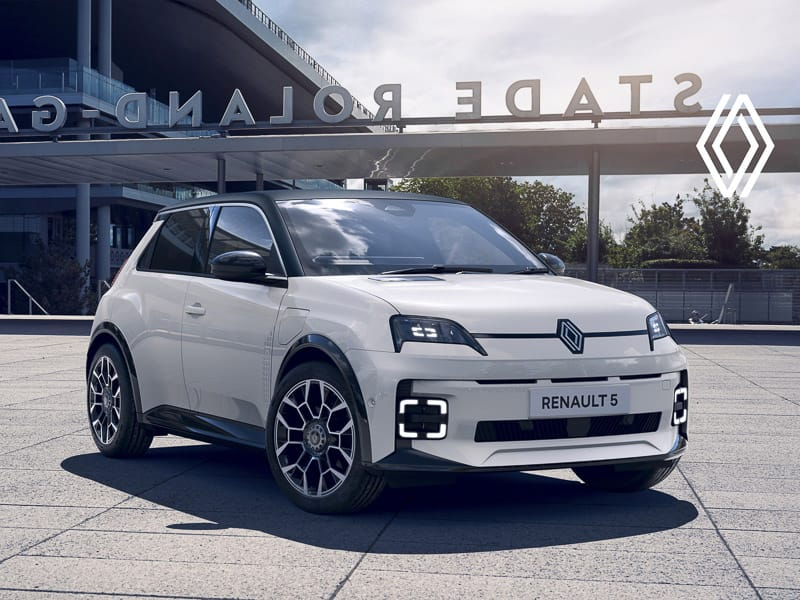

In [45]:
IMAGE_URL = "https://github.com/retkowsky/foundry-local/blob/main/car.jpg?raw=true"

with urllib.request.urlopen(IMAGE_URL) as resp:
    raw = resp.read()

display(Image(data=raw, width=640))

In [46]:
if OPENAI_AVAILABLE:
    description = describe_image(
        openai_client,
        VLM_MODEL_ID,
        image_source=IMAGE_URL,
        question="Describe this image in one sentence",
    )

Loading image from: https://github.com/retkowsky/foundry-local/blob/main/car.jpg?raw=true
Image encoded (image/jpeg, 49,512 base64 chars)

Streaming vision response:

A white Renault 5 electric hatchback is displayed in front of the Stade de Roland Garros, a modern stadium with the Renault logo prominently featured on the building's facade.



### 6.3 Visual Q&A - ask a specific question about an image


In [47]:
if OPENAI_AVAILABLE:
    questions = [
        "What is the car model? Just print the model.",
        "What is the color of the car? Just print the color.",
        "Classify this image into [truck], [car] or [byke]. Just print the result."
    ]
    
    print("\033[1;31;34m")
    
    for q in questions:
        print(f"***** Question: {q} *****\n")
        describe_image(openai_client, VLM_MODEL_ID, IMAGE_URL, question=q)


***** Question: What is the car model? Just print the model. *****

Loading image from: https://github.com/retkowsky/foundry-local/blob/main/car.jpg?raw=true
Image encoded (image/jpeg, 49,512 base64 chars)

Streaming vision response:

RENAULT 5

***** Question: What is the color of the car? Just print the color. *****

Loading image from: https://github.com/retkowsky/foundry-local/blob/main/car.jpg?raw=true
Image encoded (image/jpeg, 49,512 base64 chars)

Streaming vision response:

white

***** Question: Classify this image into [truck], [car] or [byke]. Just print the result. *****

Loading image from: https://github.com/retkowsky/foundry-local/blob/main/car.jpg?raw=true
Image encoded (image/jpeg, 49,512 base64 chars)

Streaming vision response:

car



### 6.4 Load a local image from disk


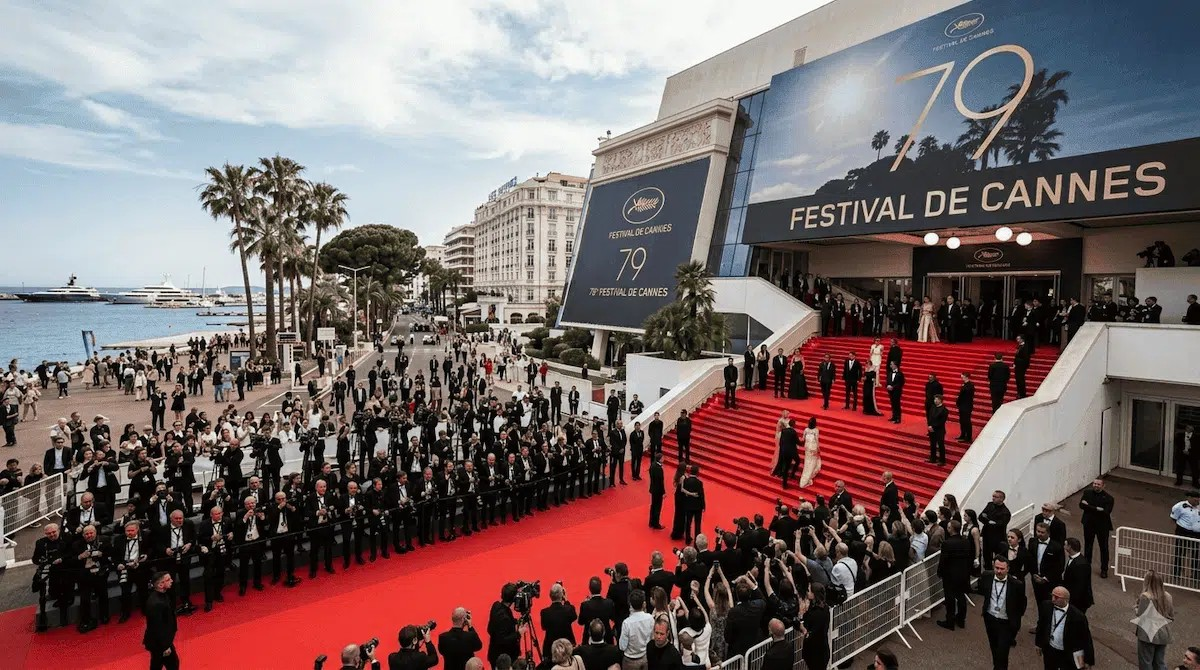

In [48]:
LOCAL_IMAGE_PATH = Path("image.jpg")

display(Image(filename=str(LOCAL_IMAGE_PATH), width=640))

In [49]:
if OPENAI_AVAILABLE and LOCAL_IMAGE_PATH.exists():
    description_local = describe_image(
        openai_client,
        VLM_MODEL_ID,
        image_source=LOCAL_IMAGE_PATH,
        question="Describe this image in one sentence",
    )

elif OPENAI_AVAILABLE:
    print(f"Local image not found: {LOCAL_IMAGE_PATH}\n"
          "Update LOCAL_IMAGE_PATH to point to an image file on disk.")

Loading image from: image.jpg
Image encoded (image/jpeg, 50,368 base64 chars)

Streaming vision response:

A large crowd of formally dressed people stands on a red carpet in front of the 79th Cannes Film Festival, with the iconic Cannes building and the Mediterranean Sea visible in the background.

